In [2]:
!pip install overturemaps geopandas shapely -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Overture Maps Data

## Overview

This project utilizes geospatial data from the **Overture Maps Foundation**, an open, interoperable global map dataset developed collaboratively by major technology companies and the open geospatial community. Overture Maps integrates data from multiple authoritative and open data providers into a standardized global map database suitable for GIS, navigation, spatial analysis, and machine learning applications.

For this project, the Overture dataset was clipped to the **Kathmandu Valley, Nepal**, and the following themes were used:

- 🏢 Buildings
- 📍 Places (Points of Interest)
- 🛣 Transportation (Road Network)
- 🌊 Water (Rivers and Water Bodies)

---

# About Overture Maps

The **Overture Maps Foundation** is a collaborative initiative established by:

- Amazon
- Meta
- Microsoft
- TomTom
- Linux Foundation

Its objective is to create a free, high-quality, regularly updated global map database that can be used for research, commercial applications, navigation systems, GIS analysis, and machine learning.

Unlike a single-source dataset, Overture combines information from multiple providers while removing duplicates, standardizing schemas, and assigning globally unique identifiers (GERS IDs).

---

# Data Collection Methodology

Overture Maps **does not collect data directly** using satellites or field surveys.

Instead, it integrates and harmonizes data from numerous trusted sources, including:

- OpenStreetMap (OSM)
- Microsoft Open Maps
- Meta Map Data
- TomTom
- Esri Community Maps
- Foursquare (Places)
- AllThePlaces
- BrightQuery
- Various governmental open datasets
- Additional commercial and open contributors

The collected datasets undergo several processing stages:

1. Data ingestion from multiple providers
2. Geometry validation
3. Duplicate detection and conflation
4. Attribute standardization
5. Global ID assignment (GERS)
6. Release generation

This process produces a consistent and globally standardized geospatial dataset.

---

# Update Frequency

Overture Maps publishes **regular versioned releases**, typically every month or every few months.

Each release includes:

- Newly added features
- Updated geometries
- Corrected attributes
- Removed duplicate features
- Improved topology
- Updated source information

Because Overture uses versioned releases, every dataset can be reproduced later using the same release version.

---

# Dataset Format

The original Overture datasets are distributed as:

- GeoParquet
- Apache Parquet
- Cloud Storage (AWS S3 / Azure Blob)

For this project, the required themes were extracted and converted into GIS-compatible formats for processing.

Typical formats include:

- GeoJSON
- GeoPackage (GPKG)
- Shapefile
- GeoParquet

---

# Coordinate Reference System

The downloaded Overture data uses:

- **WGS 84**
- **EPSG:4326**

During feature engineering and spatial analysis, the data may be reprojected into a projected CRS (e.g., UTM Zone 45N, EPSG:32645) to enable accurate metric distance and area calculations.

---

# Dataset Themes Used

---

## 1. Buildings

### Description

The Buildings theme contains building footprints represented as polygons.

Each feature corresponds to an individual building or building part.

### Geometry

- Polygon
- MultiPolygon

### Common Attributes

| Attribute | Description |
|----------|-------------|
| id | Global unique building identifier |
| geometry | Building footprint |
| bbox | Bounding box |
| names | Building name (if available) |
| height | Building height (where available) |
| levels | Number of floors (where available) |
| roof information | Roof attributes (if available) |
| source | Original data source |

### Applications

- Building density
- Urban morphology
- Population estimation
- Land use analysis
- Disaster management
- Building classification

---

## 2. Places (Points of Interest)

### Description

The Places theme contains real-world locations such as:

- Schools
- Hospitals
- Restaurants
- Shops
- Banks
- Hotels
- Government offices
- Religious sites
- Parks
- Businesses

Each feature represents a Point of Interest (POI).

### Geometry

- Point

### Common Attributes

| Attribute | Description |
|----------|-------------|
| id | Global identifier |
| names | Place name |
| categories | POI category |
| brand | Brand information |
| websites | Official website |
| phones | Contact information |
| addresses | Address details |
| confidence | Matching confidence |
| source | Data source |

### Applications

- Accessibility analysis
- POI density
- Service availability
- Urban planning
- Recommendation systems
- Location intelligence

---

## 3. Transportation

### Description

The Transportation theme represents the road network and transport infrastructure.

It includes:

- Highways
- Primary roads
- Secondary roads
- Residential roads
- Service roads
- Footpaths
- Cycleways
- Bridges
- Tunnels

### Geometry

- LineString
- MultiLineString

### Common Attributes

| Attribute | Description |
|----------|-------------|
| id | Road identifier |
| class | Road classification |
| subclass | Detailed road type |
| names | Road name |
| access | Access restrictions |
| surface | Road surface |
| bridge | Bridge indicator |
| tunnel | Tunnel indicator |
| source | Data source |

### Applications

- Network analysis
- Routing
- Accessibility
- Traffic simulation
- Shortest path computation
- Connectivity analysis

---

## 4. Water

### Description

The Water theme contains natural and artificial water features.

Examples include:

- Rivers
- Streams
- Lakes
- Reservoirs
- Canals
- Ponds

### Geometry

- Polygon
- LineString

### Common Attributes

| Attribute | Description |
|----------|-------------|
| id | Water feature identifier |
| class | Water type |
| names | Feature name |
| geometry | Water geometry |
| source | Data source |

### Applications

- Flood analysis
- Hydrology
- Environmental monitoring
- Buffer generation
- River proximity analysis

---

# Data Quality

Overture Maps improves data quality through:

- Multi-source data fusion
- Duplicate removal
- Geometry validation
- Attribute normalization
- Standardized schemas
- Continuous community improvements

However, data completeness and accuracy may vary by geographic region depending on source availability and update frequency.

---

# Advantages

- Open data
- Global coverage
- Standardized schema
- Regular updates
- High interoperability
- Cloud-native GeoParquet format
- Rich attribute information
- Suitable for GIS and Machine Learning

---

# Limitations

- Coverage varies across regions.
- Some attributes (e.g., building height or number of floors) may be missing.
- Certain POIs may be outdated or duplicated between releases.
- Data accuracy depends on the quality and recency of the original source datasets.

---

# Data Used in This Project

For this project, Overture Maps data was clipped to the Kathmandu study area and integrated into a unified geospatial database.

The following layers were used:

| Theme | Geometry | Purpose |
|-------|----------|---------|
| Buildings | Polygon | Building density, urban features |
| Places | Point | Points of Interest (POIs) |
| Transportation | Line | Road network and accessibility |
| Water | Line / Polygon | River and water proximity analysis |

These datasets serve as the primary spatial layers for feature engineering, spatial analysis, and machine learning model development.

---

# Data Release

This project uses a specific **versioned Overture Maps release** downloaded during project development. Since Overture publishes periodic releases, feature counts and attributes may differ in future versions. For reproducibility, it is recommended to document the exact release version (e.g., `2025-04-23.0` or another release) used to generate the project dataset.

---

# References

- Overture Maps Documentation
- Overture Maps Schema Reference
- Overture Maps Release Notes
- Overture Maps GitHub Repository

# Classes


In [ ]:
!overturemaps download --bbox=85.20,27.60,85.50,27.75 -f geojson --type=place -o kathmandu_raw_places.geojson


Downloading: 0 rows [00:00, ? rows/s]
Downloading: 3543 rows [00:44, 79.13 rows/s]
Downloading: 16743 rows [00:46, 480.85 rows/s]
Downloading: 33646 rows [00:47, 1139.22 rows/s]
Downloading: 40956 rows [00:48, 1509.06 rows/s]
Downloading: 40956 rows [00:48, 847.21 rows/s] 
State saved to kathmandu_raw_places.geojson.state


# Road Network

In [1]:
!overturemaps download --bbox=85.20,27.60,85.50,27.75 -f geojson --type=segment -o kathmandu_raw_roads.geojson


Downloading: 0 rows [00:00, ? rows/s]
Downloading: 1 rows [01:37, 97.37s/ rows]
Downloading: 7995 rows [01:38, 115.96 rows/s]
Downloading: 20562 rows [01:39, 366.99 rows/s]
Downloading: 35654 rows [01:40, 771.96 rows/s]
Downloading: 49723 rows [01:42, 1264.71 rows/s]
Downloading: 56573 rows [01:42, 1575.18 rows/s]
Downloading: 56573 rows [01:42, 550.52 rows/s] 
State saved to kathmandu_raw_roads.geojson.state


# Land Use

In [4]:
!overturemaps download --bbox=85.20,27.60,85.50,27.75 -f geojson --type=land_use -o kathmandu_exclusion_landuse.geojson


Downloading: 0 rows [00:00, ? rows/s]
Downloading: 1 rows [00:11, 11.03s/ rows]
Downloading: 5332 rows [00:11, 663.50 rows/s]
Downloading: 5332 rows [00:11, 469.63 rows/s]
State saved to kathmandu_exclusion_landuse.geojson.state


# River


In [2]:
!overturemaps download --bbox=85.20,27.60,85.50,27.75 -f geojson --type=water -o kathmandu_exclusion_water.geojson


Downloading: 0 rows [00:00, ? rows/s]
Downloading: 788 rows [00:03, 209.94 rows/s]
Downloading: 788 rows [00:03, 209.75 rows/s]
State saved to kathmandu_exclusion_water.geojson.state


# Building Footprint

In [2]:
!overturemaps download --bbox=85.20,27.60,85.50,27.75 -f geojson --type=building -o kathmandu_raw_buildings.geojson


Downloading: 0 rows [00:00, ? rows/s]
Downloading: 9559 rows [00:12, 743.63 rows/s]
Downloading: 16366 rows [00:13, 1453.01 rows/s]
Downloading: 23560 rows [00:13, 2449.84 rows/s]
Downloading: 64927 rows [00:15, 8287.82 rows/s]
Downloading: 106050 rows [00:16, 13180.79 rows/s]
Downloading: 128820 rows [00:17, 15603.92 rows/s]
Downloading: 164076 rows [00:18, 18368.94 rows/s]
Downloading: 202257 rows [00:23, 12563.57 rows/s]
Downloading: 242737 rows [00:24, 15521.04 rows/s]
Downloading: 277840 rows [00:26, 17978.98 rows/s]
Downloading: 315359 rows [00:27, 19789.59 rows/s]
Downloading: 352705 rows [00:29, 21482.19 rows/s]
Downloading: 391668 rows [00:30, 22996.30 rows/s]
Downloading: 398411 rows [00:30, 23132.82 rows/s]
Downloading: 443500 rows [00:32, 24276.18 rows/s]
Downloading: 477340 rows [00:33, 24753.49 rows/s]
Downloading: 508994 rows [00:35, 25172.82 rows/s]
Downloading: 519186 rows [00:35, 25359.01 rows/s]
Downloading: 534987 rows [00:36, 25512.23 rows/s]
Downloading: 578332 r

# DEM

# WorldPop Population Dataset

## Overview

The **WorldPop Population Count (100 m Resolution)** dataset was used to estimate the spatial distribution of population within the Kathmandu study area. The dataset provides gridded estimates of the number of people living in each **100 m × 100 m** raster cell.

WorldPop is developed by the **University of Southampton** in collaboration with international partners. Population estimates are generated by combining national census data with geospatial covariates such as satellite imagery, land cover, road networks, settlement layers, and machine learning-based dasymetric mapping.

---

## Dataset Characteristics

| Property | Description |
|----------|-------------|
| Dataset Type | Raster |
| Spatial Resolution | 100 m |
| Temporal Coverage | 2025 |
| CRS | WGS 84 (EPSG:4326) |
| Data Format | GeoTIFF |
| Pixel Value | Estimated population count |

---

## Applications

The WorldPop dataset was used to derive population-related features, including:

- Population density
- Population within spatial grids
- Population surrounding buildings
- Population-based features for machine learning

---

# Copernicus DEM

## Overview

The **Copernicus Global DEM (GLO-30)** dataset was used to represent terrain elevation across the Kathmandu study area. It is a global **30 m Digital Surface Model (DSM)** produced under the **Copernicus Programme** using data primarily from the **TanDEM-X mission**.

The DEM provides elevation information that supports terrain analysis and spatial feature engineering.

---

## Dataset Characteristics

| Property | Description |
|----------|-------------|
| Dataset Type | Raster |
| Spatial Resolution | 30 m |
| CRS | WGS 84 (EPSG:4326) |
| Vertical Datum | EGM2008 |
| Elevation Unit | Meters |
| Data Format | GeoTIFF |

---

## Applications

The Copernicus DEM was used to derive terrain-related features such as:

- Elevation
- Slope
- Aspect
- Terrain characteristics used in spatial analysis and machine learning

Connecting to Cloud-Optimized GeoTIFF on AWS...
Success! Saved to kathmandu_elevation_30m.tif


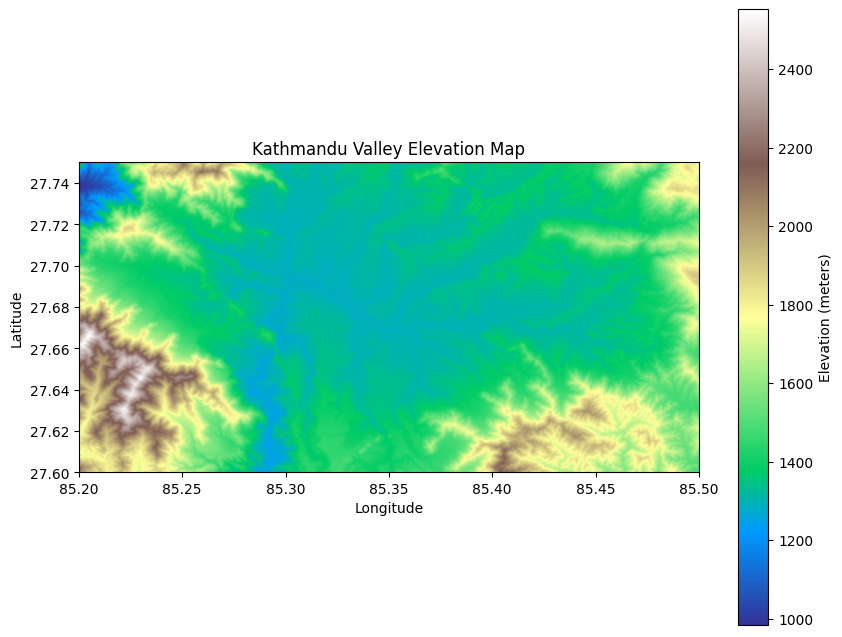

In [3]:
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

# Your exact bounding box: (min_lon, min_lat, max_lon, max_lat)
bbox = (85.20, 27.60, 85.50, 27.75)

# The public HTTP URL for the Copernicus GLO-30 tile covering your coordinates
url = "https://copernicus-dem-30m.s3.amazonaws.com/Copernicus_DSM_COG_10_N27_00_E085_00_DEM/Copernicus_DSM_COG_10_N27_00_E085_00_DEM.tif"

print(f"Connecting to Cloud-Optimized GeoTIFF on AWS...")

with rasterio.open(url) as src:
    # 1. Calculate the exact window for your bounding box
    window = from_bounds(*bbox, transform=src.transform)
    
    # 2. Read only the elevation data inside that window
    print("Downloading crop...")
    elevation_data = src.read(1, window=window)
    
    # 3. Create the spatial metadata for your new cropped file
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": window.height,
        "width": window.width,
        "transform": rasterio.windows.transform(window, src.transform)
    })

# 4. Save the cropped data locally
output_file = "kathmandu_elevation_30m.tif"
with rasterio.open(output_file, "w", **out_meta) as dest:
    dest.write(elevation_data, 1)

print(f"Success! Saved to {output_file}")

# 5. Visualize the elevation
plt.figure(figsize=(10, 8))
plt.imshow(elevation_data, cmap='terrain', extent=[bbox[0], bbox[2], bbox[1], bbox[3]])
plt.colorbar(label='Elevation (meters)')
plt.title("Kathmandu Valley Elevation Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()